In [2]:
import numpy as np
from matplotlib.lines import Line2D
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

In [5]:
with open('/home/annierosen16/master_1979_2025.pkl', 'rb') as f:
    
    master = pickle.load(f)

In [3]:
with open('/home/annierosen16/pressure.pkl', 'rb') as f:
    
    pressure = pickle.load(f)
    
with open('/home/annierosen16/sgp_latitudes.pkl', 'rb') as f:
    
    latitude = pickle.load(f)
    
with open('/home/annierosen16/sgp_longitudes.pkl', 'rb') as f:
    
    longitude = pickle.load(f)

In [ ]:
# reading in Yizhou's ERA5 q

LAT_N, LAT_S = 39, 30

LON_W, LON_E = -105, -95

WARM_MONTHS = [5, 6, 7, 8, 9]

base_path = '/data/rong4/Data/ERA5/3hourly/quvw_US'

years = [str(year) for year in range(1979, 2023)]

def get_files(folder, component):

    files = glob.glob(os.path.join(base_path, folder, f"era5.{component}.*.nc"))

    filtered_files = [f for f in files if any(year in f for year in years)]
    
    return filtered_files

def list_nc_files(path, contains=None):
    
    path = os.path.expanduser(path)
    
    files = sorted(glob.glob(os.path.join(path, "*.nc")))
    
    if contains is not None:
        
        files = [f for f in files if contains in os.path.basename(f)]
    
    return files

# Get the files for each component

q_files = get_files('specific_humidity', 'specific_humidity')

# open all datasets at once

q_yz = xr.open_mfdataset(q_files, combine='by_coords', chunks={'time': 24})

q_yz = q_yz.sel(latitude=slice(LAT_N, LAT_S), longitude=slice(LON_W, LON_E))

q_yz["time"] = q_yz["time"] - pd.Timedelta(hours=6)

q_yz = q_yz.where(
    
    (q_yz.time.dt.month.isin(WARM_MONTHS)) & (q_yz.time.dt.year.isin(range(1979, 2023))),
    
    drop=True)

In [ ]:
# -----------------------------
# Load ERA5 (your 2022–2025)
# -----------------------------

q_2022_2025_path = "~/data/era5sgp/era5_ml_q_full_sgp_2022_2025"

q_files_new = list_nc_files(q_2022_2025_path)

q_new = xr.open_mfdataset(q_files_new, combine="by_coords", chunks={"time": 24})

q_new = q_new.sel(latitude=slice(LAT_N, LAT_S), longitude=slice(LON_W, LON_E))

q_new = q_new.rename({"valid_time": "time", "pressure_level": "level"})

q_new["time"] = q_new["time"] - pd.Timedelta(hours=6)

q_new = q_new.where(
    
    (q_new.time.dt.month.isin(WARM_MONTHS)) & (q_new.time.dt.year.isin(range(2001, 2026))),
    
    drop=True)

q_new = q_new.sortby("level", ascending=True)

In [ ]:
# -----------------------------
# Combine
# -----------------------------

common_vars = sorted(set(q_yz.data_vars) & set(q_new.data_vars))

q_yz = q_yz[common_vars].drop_vars("expver", errors="ignore")

q_new = q_new[common_vars].drop_vars("expver", errors="ignore")

humidity = xr.concat([q_yz, q_new], dim="time", join="exact").sortby("time")

t = pd.Index(humidity.time.values)

dupes = t.duplicated(keep="first")

if dupes.any():
    
    humidity = humidity.isel(time=~xr.DataArray(dupes, dims="time"))

In [ ]:
pressure = humidity['level'].data * 100

In [ ]:
def integrate_q_profile(q, levels):
    
    g = 9.81  # Gravitational acceleration in m/s^2
    
    rho_water = 1000  # Density of water in kg/m^3
    
    m_to_mm = 1000
                    
    dp = np.diff(levels)
                
    integrated_q = (np.sum(0.5 * (q[:-1] + q[1:]) * dp) / (g * rho_water)) * 1000

    return integrated_q

In [ ]:
q = humidity['q'].load()

In [ ]:
column_pressure_mask = pressure <= 92500 # Pa

column_pressure_masked = pressure[column_pressure_mask]

bl_pressure_mask = (80000 <= pressure) & (pressure <= 92500) # Pa

bl_pressure_masked = pressure[bl_pressure_mask]

lt_pressure_mask = (60000 <= pressure) & (pressure < 80000) # Pa

lt_pressure_masked = pressure[lt_pressure_mask]

In [ ]:
n_time = humidity['q'].shape[0]

all_humidity_tups = []

bl_humidity_tups = []

lt_humidity_tups = []

for time_idx in range(humidity['q'].shape[0]):
    
    if time_idx % 10 == 0:
        
        print(f"Processing time {time_idx+1}/{n_time}: "
              
              f"{humidity['time'].data[time_idx]}")
        
    for lat_idx in range(humidity['q'].shape[2]):
        
        for lon_idx in range(humidity['q'].shape[3]):
            
            time = humidity['time'].data[time_idx]
            
            lat = humidity['latitude'].data[lat_idx]
            
            lon = humidity['longitude'].data[lon_idx]

            q_profile = humidity['q'].data[time_idx, :, lat_idx, lon_idx]

            column_q_profile = q_profile[column_pressure_mask]
            
            bl_q_profile = q_profile[bl_pressure_mask]
            
            lt_q_profile = q_profile[lt_pressure_mask]
            
            # full column 

            q_integrated = integrate_q_profile(column_q_profile, column_pressure_masked)
            
            tup = (time, lat, lon, q_integrated)
                        
            all_humidity_tups.append(tup) 
            
            # boundary layer 
            
            bl_q_integrated = integrate_q_profile(bl_q_profile, bl_pressure_masked)
            
            bl_tup = (time, lat, lon, bl_q_integrated)
            
            bl_humidity_tups.append(bl_tup)
            
            # lt layer 
            
            lt_q_integrated = integrate_q_profile(lt_q_profile, lt_pressure_masked)
                        
            lt_tup = (time, lat, lon, lt_q_integrated)         
            
            lt_humidity_tups.append(lt_tup)

In [ ]:
humidity_df = pd.DataFrame(all_humidity_tups, columns=["time", "lat", "lon", "int_q"])

bl_df = pd.DataFrame(bl_humidity_tups, columns=["time", "lat", "lon", "bl_int_q"])

lt_df = pd.DataFrame(lt_humidity_tups, columns=["time", "lat", "lon", "lt_int_q"])

all_layers_df = (humidity_df.merge(bl_df, on=["time", "lat", "lon"], how="inner").merge(lt_df, on=["time", "lat", "lon"], how="inner"))

all_layers_df['date'] = pd.to_datetime(all_layers_df['time']).dt.date

In [ ]:
# # out_path = "/home/annierosen16/all_layers_df_1979_2025.pkl"

# # all_layers_df.to_pickle(out_path)

# # print(f"Saved all_layers_df to {out_path}")

# out_dir = "/home/annierosen16/all_layers_df_1979_2025_parts"

# os.makedirs(out_dir, exist_ok=True)

# n = len(all_layers_df)

# edges = np.linspace(0, n, 4, dtype=int)  # 3 chunks => 4 edges

# paths = []

# for i in range(3):
    
#     part = all_layers_df.iloc[edges[i]:edges[i+1]].copy()
    
#     p = os.path.join(out_dir, f"all_layers_df_1979_2025_part{i+1:02d}_of_03.pkl")
    
#     part.to_pickle(p)
    
#     paths.append(p)
    
#     print(f"Saved part {i+1}/3: {p}  (rows {edges[i]}:{edges[i+1]})")

In [6]:
## read back in all_layers_df (so you don't have to go through re-creating it again)

# in_path = "/home/annierosen16/all_layers_df_1979_2025.pkl"

# all_layers_df = pd.read_pickle(in_path)

# print("Loaded all_layers_df")

# print(all_layers_df.head())

paths = sorted(glob.glob("/home/annierosen16/all_layers_df_1979_2025_parts/*.pkl"))

dfs = [pd.read_pickle(p) for p in paths]

all_layers_df = pd.concat(dfs, ignore_index=True)

# If you need guaranteed time order afterwards:

# all_layers_df = all_layers_df.sort_values("time").reset_index(drop=True)

In [7]:
diurnal_q_df = (
    
    all_layers_df.groupby(['date', 'lat', 'lon']).agg({
        
        'int_q': list,
        
        'bl_int_q': list,
        
        'lt_int_q': list
    
    })
    
    .reset_index()
    
    .rename(columns={
        
        'int_q': 'diurnal_q',
        
        'bl_int_q': 'diurnal_bl_q',
        
        'lt_int_q': 'diurnal_lt_q'
    })
)

In [8]:
def diurnal_derivative(q_list):
    
    q_array = np.array(q_list)
    
    # central differences when possible, uses 2*dt_hours = 6
    
    # for edge points, uses dt_hours
    
    dt_hours = 3
    
    dq_dt = np.gradient(q_array, dt_hours)  # mm/hour
    
    return list(dq_dt * 24)  # mm/day

In [9]:
diurnal_q_df['diurnal_dqdt'] = diurnal_q_df['diurnal_q'].apply(diurnal_derivative)

print("dqdt complete")

diurnal_q_df['diurnal_bl_dqdt'] = diurnal_q_df['diurnal_bl_q'].apply(diurnal_derivative)

print("bl dqdt complete")

diurnal_q_df['diurnal_lt_dqdt'] = diurnal_q_df['diurnal_lt_q'].apply(diurnal_derivative)

print("lt dqdt complete")

diurnal_q_df_renamed = diurnal_q_df.rename(columns={'lat': 'latitude', 'lon': 'longitude'})

dqdt complete
bl dqdt complete
lt dqdt complete


In [10]:
master['date'] = pd.to_datetime(master['date'])

diurnal_q_df_renamed['date'] = pd.to_datetime(diurnal_q_df_renamed['date'])

master_time_tendency = master.merge(diurnal_q_df_renamed[['date', 'latitude', 'longitude', 'diurnal_q','diurnal_dqdt', 'diurnal_bl_q','diurnal_bl_dqdt', 'diurnal_lt_q', 'diurnal_lt_dqdt']],
    
                                    on=['date', 'latitude', 'longitude'],
                                    
                                    how='left')

In [11]:
## drop day = 9/30 because we are missing complete precipitation and q information for that day 

dates = pd.to_datetime(master_time_tendency["date"])

master_time_tendency = master_time_tendency[~((dates.dt.month == 9) & (dates.dt.day == 30))].copy()

In [12]:
dryapes = master_time_tendency[master_time_tendency['dryape'] == True]

wetapes = master_time_tendency[master_time_tendency['wetape'] == True]

drycoupling = master_time_tendency[(master_time_tendency['dryape']==False) & (master_time_tendency['drycoupling']==True)]

wetcoupling = master_time_tendency[(master_time_tendency['wetape']==False) & (master_time_tendency['wetcoupling']==True)]

In [13]:
## define full column diurnal dqdt here

dry_stacked = np.stack(dryapes['diurnal_dqdt'].values)

diurnal_time_tendency_dry = dry_stacked.mean(axis=0)

diurnal_time_tendency_dry_std = dry_stacked.std(axis=0, ddof=1)

wet_stacked = np.stack(wetapes['diurnal_dqdt'].values)

diurnal_time_tendency_wet = wet_stacked.mean(axis=0)

diurnal_time_tendency_wet_std = wet_stacked.std(axis=0, ddof=1)

In [21]:
# ## testing

# hours = list(range(len(diurnal_time_tendency_dry)))

# n_dry = dryapes.shape[0]

# n_wet = wetapes.shape[0]

# dry_sem = diurnal_time_tendency_dry_std / np.sqrt(n_dry)

# wet_sem = diurnal_time_tendency_wet_std / np.sqrt(n_wet)

# ci_constant = 1.96
# lw = 1.2
# ci_alpha = 0.35

# fig, ax = plt.subplots(figsize=(10, 5))

# ax.plot(hours, diurnal_time_tendency_dry, color='#d95f02', lw=lw, label='Dry APEs')
# ax.fill_between(hours,
#                 diurnal_time_tendency_dry - (ci_constant * dry_sem),
#                 diurnal_time_tendency_dry + (ci_constant * dry_sem),
#                 color='grey', alpha=ci_alpha)

# ax.plot(hours, diurnal_time_tendency_wet, color='#7570b3', lw=lw, label='Wet APEs')
# ax.fill_between(hours,
#                 diurnal_time_tendency_wet - (ci_constant * wet_sem),
#                 diurnal_time_tendency_wet + (ci_constant * wet_sem),
#                 color='grey', alpha=ci_alpha)


# ax.axhline(0, color='black', linestyle='--', linewidth=1)
# ax.set_xlabel('Hour (LST)')
# ax.set_ylabel(r'$\partial q / \partial t$ (units)')
# ax.set_title('Diurnal Moisture Tendency — Dry APEs')
# ax.set_xticks(hours[::3])
# ax.grid(True, linestyle='--', alpha=0.4)
# ax.legend(frameon=False)

# plt.tight_layout()
# plt.show()

In [14]:
## define BL diurnal dqdt here

bl_dry_stacked = np.stack(dryapes['diurnal_bl_dqdt'])

bl_diurnal_time_tendency_dry = bl_dry_stacked.mean(axis=0)

bl_diurnal_time_tendency_dry_std = bl_dry_stacked.std(axis=0, ddof=1)

bl_wet_stacked = np.stack(wetapes['diurnal_bl_dqdt'])

bl_diurnal_time_tendency_wet = bl_wet_stacked.mean(axis=0)

bl_diurnal_time_tendency_wet_std = bl_wet_stacked.std(axis=0, ddof=1)

## define LT diurnal dqdt here

lt_dry_stacked = np.stack(dryapes['diurnal_lt_dqdt'])

lt_diurnal_time_tendency_dry = lt_dry_stacked.mean(axis=0)

lt_diurnal_time_tendency_dry_std = lt_dry_stacked.std(axis=0, ddof=1)

lt_wet_stacked = np.stack(wetapes['diurnal_lt_dqdt'])

lt_diurnal_time_tendency_wet = lt_wet_stacked.mean(axis=0)

lt_diurnal_time_tendency_wet_std = lt_wet_stacked.std(axis=0, ddof=1)

In [35]:
with open('/home/annierosen16/diurnal_time_tendency_1979_2025.pkl', 'wb') as f:
    
    pickle.dump({
        
        'dry': diurnal_time_tendency_dry,
        
        'wet': diurnal_time_tendency_wet
    
    }, f)
    
# dump boundary layer time tendency 

with open('/home/annierosen16/bl_diurnal_time_tendency_1979_2025.pkl', 'wb') as f:
    
    pickle.dump({
        
        'dry': bl_diurnal_time_tendency_dry,
        
        'wet': bl_diurnal_time_tendency_wet
    
    }, f)

# dump lt time tendency 

with open('/home/annierosen16/lt_diurnal_time_tendency_1979_2025.pkl', 'wb') as f:
    
    pickle.dump({
        
        'dry': lt_diurnal_time_tendency_dry,
        
        'wet': lt_diurnal_time_tendency_wet
    
    }, f)

In [27]:
# dump full column time tendency std

with open('/home/annierosen16/diurnal_time_tendency_std_1979_2025.pkl', 'wb') as f:
    
    pickle.dump({
        
        'dry': diurnal_time_tendency_dry_std,
        
        'wet': diurnal_time_tendency_wet_std
    
    }, f)

# dump boundary layer time tendency std

with open('/home/annierosen16/bl_diurnal_time_tendency_std_1979_2025.pkl', 'wb') as f:
    
    pickle.dump({
        
        'dry': bl_diurnal_time_tendency_dry_std,
        
        'wet': bl_diurnal_time_tendency_wet_std
    
    }, f)

# dump lt time tendency std

with open('/home/annierosen16/lt_diurnal_time_tendency_std_1979_2025.pkl', 'wb') as f:
    
    pickle.dump({
        
        'dry': lt_diurnal_time_tendency_dry_std,
        
        'wet': lt_diurnal_time_tendency_wet_std
    
    }, f)

In [ ]:
# with open('/home/annierosen16/diurnal_time_tendency.pkl', 'rb') as f:
    
#     data = pickle.load(f)

# diurnal_time_tendency_dry = list(data['dry'])

# diurnal_time_tendency_wet = list(data['wet'])

## integrated full column q

In [15]:
def mean_and_se(stacked_array, n_eff):
    
    """
    stacked_array: (N_samples, N_hours)
    n_eff: effective sample size (number of unique dates)
    
    Returns:
        mean  : composite mean
        se    : standard error using effective sample size
    """
    
    mean = np.mean(stacked_array, axis=0)
    
    std  = np.std(stacked_array, axis=0, ddof=1)
    
    se = std / np.sqrt(n_eff)
    
    return mean, se, std

In [16]:
# -------------------------
# FULL COLUMN (TCWV)
# -------------------------

dryapes_cwv_stacked      = np.stack(dryapes['diurnal_q'].values)

wetapes_cwv_stacked      = np.stack(wetapes['diurnal_q'].values)

drycoupling_cwv_stacked  = np.stack(drycoupling['diurnal_q'].values)

wetcoupling_cwv_stacked  = np.stack(wetcoupling['diurnal_q'].values)

# -------------------------
# BOUNDARY LAYER
# -------------------------

bl_dryapes_cwv_stacked     = np.stack(dryapes['diurnal_bl_q'].values)

bl_wetapes_cwv_stacked     = np.stack(wetapes['diurnal_bl_q'].values)

bl_drycoupling_cwv_stacked = np.stack(drycoupling['diurnal_bl_q'].values)

bl_wetcoupling_cwv_stacked = np.stack(wetcoupling['diurnal_bl_q'].values)

# -------------------------
# LOWER TROPOSPHERE
# -------------------------

lt_dryapes_cwv_stacked     = np.stack(dryapes['diurnal_lt_q'].values)

lt_wetapes_cwv_stacked     = np.stack(wetapes['diurnal_lt_q'].values)

lt_drycoupling_cwv_stacked = np.stack(drycoupling['diurnal_lt_q'].values)

lt_wetcoupling_cwv_stacked = np.stack(wetcoupling['diurnal_lt_q'].values)

In [17]:
n_dry_dates  = dryapes.shape[0]

n_wet_dates  = wetapes.shape[0]

n_dryc_dates = drycoupling.shape[0]

n_wetc_dates = wetcoupling.shape[0]

# ===============================
# Full Column APEs
# ===============================

diurnal_cwv_dryapes, se_dryapes, std_dryapes = mean_and_se(
    
    dryapes_cwv_stacked, n_dry_dates
)

diurnal_cwv_wetapes, se_wetapes, std_wetapes = mean_and_se(
    
    wetapes_cwv_stacked, n_wet_dates
)


# ===============================
# Full Column Coupling
# ===============================

diurnal_cwv_drycoupling, se_drycoupling, std_drycoupling = mean_and_se(
    
    drycoupling_cwv_stacked, n_dryc_dates

)

diurnal_cwv_wetcoupling, se_wetcoupling, std_wetcoupling = mean_and_se(
    
    wetcoupling_cwv_stacked, n_wetc_dates
)


# ===============================
# BL APEs
# ===============================

bl_diurnal_cwv_dryapes, bl_se_dryapes, bl_std_dryapes = mean_and_se(
    
    bl_dryapes_cwv_stacked, n_dry_dates
)

bl_diurnal_cwv_wetapes, bl_se_wetapes, bl_std_wetapes = mean_and_se(
    
    bl_wetapes_cwv_stacked, n_wet_dates

)


# ===============================
# BL Coupling
# ===============================

bl_diurnal_cwv_drycoupling, bl_se_drycoupling, bl_std_drycoupling = mean_and_se(
    
    bl_drycoupling_cwv_stacked, n_dryc_dates

)

bl_diurnal_cwv_wetcoupling, bl_se_wetcoupling, bl_std_wetcoupling = mean_and_se(
    
    bl_wetcoupling_cwv_stacked, n_wetc_dates

)


# ===============================
# LT APEs
# ===============================

lt_diurnal_cwv_dryapes, lt_se_dryapes, lt_std_dryapes = mean_and_se(
    
    lt_dryapes_cwv_stacked, n_dry_dates

)

lt_diurnal_cwv_wetapes, lt_se_wetapes, lt_std_wetapes = mean_and_se(
    
    lt_wetapes_cwv_stacked, n_wet_dates

)


# ===============================
# LT Coupling
# ===============================

lt_diurnal_cwv_drycoupling, lt_se_drycoupling, lt_std_drycoupling = mean_and_se(
    
    lt_drycoupling_cwv_stacked, n_dryc_dates

)

lt_diurnal_cwv_wetcoupling, lt_se_wetcoupling, lt_std_wetcoupling = mean_and_se(
    
    lt_wetcoupling_cwv_stacked, n_wetc_dates
)

### plots for total CWV, boundary layer q and LT q integrated:

In [48]:
# # -------------------------
# # 3) Plot styling
# # -------------------------
# hours = np.arange(0, 24, 3)

# COLORS = {
#     "dry": "#D55E00",   # muted vermillion
#     "wet": "#0072B2",   # muted blue
# }

# plt.rcParams.update({
#     "font.size": 12,
#     "axes.titlesize": 14,
#     "axes.labelsize": 13,
#     "legend.fontsize": 11,
#     "xtick.labelsize": 11,
#     "ytick.labelsize": 11
# })

# # -------------------------
# # 4) Plot function with SE shading + panel labels + caption (no overlap)
# # -------------------------
# def plot_diurnal_cwv_3panel(hours,
#                             # Total column
#                             cwv_dry, cwv_wet, cwv_dryc, cwv_wetc,
#                             cwv_se_dry, cwv_se_wet, cwv_se_dryc, cwv_se_wetc,
#                             # BL
#                             bl_dry,  bl_wet,  bl_dryc,  bl_wetc,
#                             bl_se_dry, bl_se_wet, bl_se_dryc, bl_se_wetc,
#                             # LT
#                             lt_dry,  lt_wet,  lt_dryc,  lt_wetc,
#                             lt_se_dry, lt_se_wet, lt_se_dryc, lt_se_wetc,
#                             # Caption inputs
#                             n_dry_dates=None, n_wet_dates=None, n_dryc_dates=None, n_wetc_dates=None,
#                             add_caption=True):

#     # IMPORTANT: remove constrained_layout so we can reserve space for caption reliably
#     fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
#     fig.suptitle(r"$\bf{Figure\ 1}$", fontsize=16, y=0.94)

#     panels = [
#         (axes[0],
#          cwv_dry, cwv_wet, cwv_dryc, cwv_wetc,
#          cwv_se_dry, cwv_se_wet, cwv_se_dryc, cwv_se_wetc,
#          "Total Column Water Vapor", "kg m$^{-2}$"),

#         (axes[1],
#          bl_dry, bl_wet, bl_dryc, bl_wetc,
#          bl_se_dry, bl_se_wet, bl_se_dryc, bl_se_wetc,
#          "Integrated Boundary-Layer Water Vapor", "kg m$^{-2}$"),

#         (axes[2],
#          lt_dry, lt_wet, lt_dryc, lt_wetc,
#          lt_se_dry, lt_se_wet, lt_se_dryc, lt_se_wetc,
#          "Integrated Lower-Tropospheric Water Vapor", "kg m$^{-2}$"),
#     ]

#     panel_labels = ["(a)", "(b)", "(c)"]

#     for i, (ax, dry, wet, dryc, wetc, se_dry, se_wet, se_dryc, se_wetc, title, ylabel) in enumerate(panels):

#         # --- APEs (solid) ---
        
#         ax.plot(hours, dry, color=COLORS["dry"], linewidth=2, label="Dry APEs")
        
#         ax.fill_between(hours, dry - se_dry, dry + se_dry,
                        
#                         color='grey', alpha=0.8)

#         ax.plot(hours, wet, color=COLORS["wet"], linewidth=2, label="Wet APEs")
        
#         ax.fill_between(hours, wet - se_wet, wet + se_wet,
                        
#                         color='grey', alpha=0.8)

#         # --- Coupling (dashed) ---
        
#         ax.plot(hours, dryc, color=COLORS["dry"], linestyle="--", linewidth=1.8, label="Dry Coupling")
        
#         ax.fill_between(hours, dryc - se_dryc, dryc + se_dryc,
                        
#                         color='grey', alpha=0.8)

#         ax.plot(hours, wetc, color=COLORS["wet"], linestyle="--", linewidth=1.8, label="Wet Coupling")
        
#         ax.fill_between(hours, wetc - se_wetc, wetc + se_wetc,
                        
#                         color='grey', alpha=0.8)

#         ax.set_title(title)
#         ax.set_ylabel(ylabel)
#         ax.grid(alpha=0.3)

#         # Panel labels in upper-right
#         ax.text(0.98, 0.97, panel_labels[i],
                
#                 transform=ax.transAxes,
                
#                 va="top", ha="right",
                
#                 fontsize=12, fontweight="bold")

#     axes[-1].set_xlabel("Local Time (LST)")
#     axes[-1].set_xticks(hours)
#     axes[0].legend(ncol=2, frameon=False, loc="upper left")

#     # -------------------------
#     # Caption (below the panels) + reserve space cleanly
#     # -------------------------
#     if add_caption:
#         n_text = ""
#         if all(v is not None for v in [n_dry_dates, n_wet_dates, n_dryc_dates, n_wetc_dates]):
#             n_text = (f" Effective sample sizes (unique dates) were: "
#                       f"dry APEs n={n_dry_dates}, wet APEs n={n_wet_dates}, "
#                       f"dry coupling n={n_dryc_dates}, wet coupling n={n_wetc_dates}.")

#         caption = (
#             "Figure 1. Diurnal cycle of composite (a) total column water vapor, "
#             "(b) integrated boundary-layer water vapor (925-800 hPa), and (c) integrated lower-tropospheric water vapor (800-600 hPa) "
#             "for dry APEs (solid orange), wet APEs (solid blue), dry coupling (dashed orange), and wet coupling (dashed blue). "
#             "Shading shows ±1 standard error of the mean at each local time. Standard error was computed as "
#             r"$SE=\sigma/\sqrt{n_{\mathrm{eff}}}$, where $\sigma$ is the sample standard deviation across all date–gridpoint samples "
#             r"and $n_{\mathrm{eff}}$ is the number of unique dates in each composite."
#             + n_text
#         )

#         # Put caption near bottom, then reserve bottom margin using tight_layout rect
#         fig.text(0.5, 0.02, caption, ha="center", va="bottom", fontsize=10, wrap=True)

#         # Reserve space: bottom for caption, top for title
#         plt.tight_layout(rect=[0, 0.13, 1, 0.96])
    
#     else:
#         plt.tight_layout(rect=[0, 0.02, 1, 0.96])

#     plt.show()


# # -------------------------
# # 5) Call the plot function
# # -------------------------
# plot_diurnal_cwv_3panel(
#     hours,
#     # Total column
#     diurnal_cwv_dryapes,
#     diurnal_cwv_wetapes,
#     diurnal_cwv_drycoupling,
#     diurnal_cwv_wetcoupling,
#     se_dryapes,
#     se_wetapes,
#     se_drycoupling,
#     se_wetcoupling,
#     # BL
#     bl_diurnal_cwv_dryapes,
#     bl_diurnal_cwv_wetapes,
#     bl_diurnal_cwv_drycoupling,
#     bl_diurnal_cwv_wetcoupling,
#     bl_se_dryapes,
#     bl_se_wetapes,
#     bl_se_drycoupling,
#     bl_se_wetcoupling,
#     # LT
#     lt_diurnal_cwv_dryapes,
#     lt_diurnal_cwv_wetapes,
#     lt_diurnal_cwv_drycoupling,
#     lt_diurnal_cwv_wetcoupling,
#     lt_se_dryapes,
#     lt_se_wetapes,
#     lt_se_drycoupling,
#     lt_se_wetcoupling,
#     # optional caption sample sizes (if you have them defined)
#     n_dry_dates=n_dry_dates if "n_dry_dates" in globals() else None,
#     n_wet_dates=n_wet_dates if "n_wet_dates" in globals() else None,
#     n_dryc_dates=n_dryc_dates if "n_dryc_dates" in globals() else None,
#     n_wetc_dates=n_wetc_dates if "n_wetc_dates" in globals() else None,
#     add_caption=True
# )

In [ ]:
# ## read these back in if you want to plot 

# with open('/home/annierosen16/diurnal_cwv_means_1979_2025.pkl', 'wb') as f:
    
#     pickle.dump({
#         'dryapes':     diurnal_cwv_dryapes,
#         'wetapes':     diurnal_cwv_wetapes,
#         'drycoupling': diurnal_cwv_drycoupling,
#         'wetcoupling': diurnal_cwv_wetcoupling,
#     }, f)

# with open('/home/annierosen16/diurnal_cwv_se_1979_2025.pkl', 'wb') as f:
    
#     pickle.dump({
#         'dryapes':     se_dryapes,
#         'wetapes':     se_wetapes,
#         'drycoupling': se_drycoupling,
#         'wetcoupling': se_wetcoupling,
#     }, f)

# with open('/home/annierosen16/diurnal_cwv_std_1979_2025.pkl', 'wb') as f:
    
#     pickle.dump({
#         'dryapes':     std_dryapes,
#         'wetapes':     std_wetapes,
#         'drycoupling': std_drycoupling,
#         'wetcoupling': std_wetcoupling,
#     }, f)

# # Boundary layer CWV
# with open('/home/annierosen16/bl_diurnal_cwv_means_1979_2025.pkl', 'wb') as f:
    
#     pickle.dump({
#         'dryapes':     bl_diurnal_cwv_dryapes,
#         'wetapes':     bl_diurnal_cwv_wetapes,
#         'drycoupling': bl_diurnal_cwv_drycoupling,
#         'wetcoupling': bl_diurnal_cwv_wetcoupling,
#     }, f)

# with open('/home/annierosen16/bl_diurnal_cwv_se_1979_2025.pkl', 'wb') as f:
    
#     pickle.dump({
#         'dryapes':     bl_se_dryapes,
#         'wetapes':     bl_se_wetapes,
#         'drycoupling': bl_se_drycoupling,
#         'wetcoupling': bl_se_wetcoupling,
#     }, f)

# with open('/home/annierosen16/bl_diurnal_cwv_std_1979_2025.pkl', 'wb') as f:
    
#     pickle.dump({
#         'dryapes':     bl_std_dryapes,
#         'wetapes':     bl_std_wetapes,
#         'drycoupling': bl_std_drycoupling,
#         'wetcoupling': bl_std_wetcoupling,
#     }, f)

# # Lower troposphere CWV
# with open('/home/annierosen16/lt_diurnal_cwv_means_1979_2025.pkl', 'wb') as f:
    
#     pickle.dump({
#         'dryapes':     lt_diurnal_cwv_dryapes,
#         'wetapes':     lt_diurnal_cwv_wetapes,
#         'drycoupling': lt_diurnal_cwv_drycoupling,
#         'wetcoupling': lt_diurnal_cwv_wetcoupling,
#     }, f)

# with open('/home/annierosen16/lt_diurnal_cwv_se_1979_2025.pkl', 'wb') as f:
    
#     pickle.dump({
#         'dryapes':     lt_se_dryapes,
#         'wetapes':     lt_se_wetapes,
#         'drycoupling': lt_se_drycoupling,
#         'wetcoupling': lt_se_wetcoupling,
#     }, f)

# with open('/home/annierosen16/lt_diurnal_cwv_std_1979_2025.pkl', 'wb') as f:
    
#     pickle.dump({
#         'dryapes':     lt_std_dryapes,
#         'wetapes':     lt_std_wetapes,
#         'drycoupling': lt_std_drycoupling,
#         'wetcoupling': lt_std_wetcoupling,
#     }, f)

# print("All CWV files saved.")

In [3]:
## read all integrated CWV arrays back in 

# Full-column CWV

with open('/home/annierosen16/diurnal_cwv_means_1979_2025.pkl', 'rb') as f:
    
    cwv_means = pickle.load(f)

with open('/home/annierosen16/diurnal_cwv_se_1979_2025.pkl', 'rb') as f:
    
    cwv_se = pickle.load(f)

with open('/home/annierosen16/diurnal_cwv_std_1979_2025.pkl', 'rb') as f:
    
    cwv_std = pickle.load(f)

# Boundary layer CWV
with open('/home/annierosen16/bl_diurnal_cwv_means_1979_2025.pkl', 'rb') as f:
    
    bl_cwv_means = pickle.load(f)

with open('/home/annierosen16/bl_diurnal_cwv_se_1979_2025.pkl', 'rb') as f:
    
    bl_cwv_se = pickle.load(f)

with open('/home/annierosen16/bl_diurnal_cwv_std_1979_2025.pkl', 'rb') as f:
    bl_cwv_std = pickle.load(f)

# Lower troposphere CWV
with open('/home/annierosen16/lt_diurnal_cwv_means_1979_2025.pkl', 'rb') as f:
    
    lt_cwv_means = pickle.load(f)

with open('/home/annierosen16/lt_diurnal_cwv_se_1979_2025.pkl', 'rb') as f:
    
    lt_cwv_se = pickle.load(f)

with open('/home/annierosen16/lt_diurnal_cwv_std_1979_2025.pkl', 'rb') as f:
    
    lt_cwv_std = pickle.load(f)

print("All CWV files loaded.")

All CWV files loaded.


In [4]:
# Full-column CWV

diurnal_cwv_dryapes     = cwv_means['dryapes']

diurnal_cwv_wetapes     = cwv_means['wetapes']

diurnal_cwv_drycoupling = cwv_means['drycoupling']

diurnal_cwv_wetcoupling = cwv_means['wetcoupling']

se_dryapes     = cwv_se['dryapes']

se_wetapes     = cwv_se['wetapes']

se_drycoupling = cwv_se['drycoupling']

se_wetcoupling = cwv_se['wetcoupling']

std_dryapes     = cwv_std['dryapes']

std_wetapes     = cwv_std['wetapes']

std_drycoupling = cwv_std['drycoupling']

std_wetcoupling = cwv_std['wetcoupling']

# Boundary layer CWV

bl_diurnal_cwv_dryapes     = bl_cwv_means['dryapes']

bl_diurnal_cwv_wetapes     = bl_cwv_means['wetapes']

bl_diurnal_cwv_drycoupling = bl_cwv_means['drycoupling']

bl_diurnal_cwv_wetcoupling = bl_cwv_means['wetcoupling']

bl_se_dryapes     = bl_cwv_se['dryapes']

bl_se_wetapes     = bl_cwv_se['wetapes']

bl_se_drycoupling = bl_cwv_se['drycoupling']

bl_se_wetcoupling = bl_cwv_se['wetcoupling']

bl_std_dryapes     = bl_cwv_std['dryapes']

bl_std_wetapes     = bl_cwv_std['wetapes']

bl_std_drycoupling = bl_cwv_std['drycoupling']

bl_std_wetcoupling = bl_cwv_std['wetcoupling']

# Lower troposphere CWV

lt_diurnal_cwv_dryapes     = lt_cwv_means['dryapes']

lt_diurnal_cwv_wetapes     = lt_cwv_means['wetapes']

lt_diurnal_cwv_drycoupling = lt_cwv_means['drycoupling']

lt_diurnal_cwv_wetcoupling = lt_cwv_means['wetcoupling']

lt_se_dryapes     = lt_cwv_se['dryapes']

lt_se_wetapes     = lt_cwv_se['wetapes']

lt_se_drycoupling = lt_cwv_se['drycoupling']

lt_se_wetcoupling = lt_cwv_se['wetcoupling']

lt_std_dryapes     = lt_cwv_std['dryapes']

lt_std_wetapes     = lt_cwv_std['wetapes']

lt_std_drycoupling = lt_cwv_std['drycoupling']

lt_std_wetcoupling = lt_cwv_std['wetcoupling']

In [11]:
def plot_diurnal_cwv_3panel_journal(
    hours,
    # Total column means
    cwv_dry=None, cwv_wet=None, cwv_dryc=None, cwv_wetc=None,
    # Total column SE
    cwv_se_dry=None, cwv_se_wet=None, cwv_se_dryc=None, cwv_se_wetc=None,
    # Total column STD
    cwv_std_dry=None, cwv_std_wet=None, cwv_std_dryc=None, cwv_std_wetc=None,
    # BL means
    bl_dry=None, bl_wet=None, bl_dryc=None, bl_wetc=None,
    # BL SE
    bl_se_dry=None, bl_se_wet=None, bl_se_dryc=None, bl_se_wetc=None,
    # BL STD
    bl_std_dry=None, bl_std_wet=None, bl_std_dryc=None, bl_std_wetc=None,
    # LT means
    lt_dry=None, lt_wet=None, lt_dryc=None, lt_wetc=None,
    # LT SE
    lt_se_dry=None, lt_se_wet=None, lt_se_dryc=None, lt_se_wetc=None,
    # LT STD
    lt_std_dry=None, lt_std_wet=None, lt_std_dryc=None, lt_std_wetc=None,
    # layout opts
    ylim_pad_frac=0.08,
    show_suptitle=False,
    suptitle="Diurnal composite water vapor",
    savepath='/home/annierosen16/diurnal_cwv_3panel.png',
    dpi=300,
    colors=None,
    fig_size=(7.2, 8.8),
    legend_y=1.02,
    top_pad=0.14,
    # caption controls
    add_caption=True,
    caption_fontsize=10,
    caption_y=0.02,
    shading='ci',  # options: 'ci', 'se', 'std'
):
    """
    Journal-style 3-panel diurnal composite plot with legends ABOVE top panel,
    and extra top margin reserved so legends never collide with panel titles.
    shading: 'ci' = 95% CI (1.96 * SE), 'se' = ±1 SE, 'std' = ±1 std dev
    Note: if shading='std', pass std arrays via *_std_* arguments.
          if shading='ci' or 'se', pass SE arrays via *_se_* arguments.
    """

    assert shading in ('ci', 'se', 'std'), "shading must be 'ci', 'se', or 'std'"

    # --- Select spread arrays and multiplier based on shading mode ---
    if shading == 'std':
        assert all(v is not None for v in [
            cwv_std_dry, cwv_std_wet, cwv_std_dryc, cwv_std_wetc,
            bl_std_dry,  bl_std_wet,  bl_std_dryc,  bl_std_wetc,
            lt_std_dry,  lt_std_wet,  lt_std_dryc,  lt_std_wetc,
        ]), "Must provide all std arrays when shading='std'"

        spread = {
            'cwv': (cwv_std_dry, cwv_std_wet, cwv_std_dryc, cwv_std_wetc),
            'bl':  (bl_std_dry,  bl_std_wet,  bl_std_dryc,  bl_std_wetc),
            'lt':  (lt_std_dry,  lt_std_wet,  lt_std_dryc,  lt_std_wetc),
        }
        multiplier = 1.0

    else:
        assert all(v is not None for v in [
            cwv_se_dry, cwv_se_wet, cwv_se_dryc, cwv_se_wetc,
            bl_se_dry,  bl_se_wet,  bl_se_dryc,  bl_se_wetc,
            lt_se_dry,  lt_se_wet,  lt_se_dryc,  lt_se_wetc,
        ]), "Must provide all SE arrays when shading='ci' or 'se'"

        spread = {
            'cwv': (cwv_se_dry, cwv_se_wet, cwv_se_dryc, cwv_se_wetc),
            'bl':  (bl_se_dry,  bl_se_wet,  bl_se_dryc,  bl_se_wetc),
            'lt':  (lt_se_dry,  lt_se_wet,  lt_se_dryc,  lt_se_wetc),
        }
        multiplier = 1.96 if shading == 'ci' else 1.0

    if colors is None:
        colors = {"dry": "#7A3E00", "wet": "#1F4E79"}

    plt.rcParams.update({
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })

    fig, axes = plt.subplots(3, 1, figsize=fig_size, sharex=True)

    if show_suptitle:
        fig.suptitle(suptitle, y=legend_y + 0.02, fontsize=13, fontweight="bold")

    panels = [
        ("Total column water vapor", "kg m$^{-2}$",
         cwv_dry, cwv_wet, cwv_dryc, cwv_wetc,
         *spread['cwv']),

        ("Integrated boundary-layer water vapor (925–800 hPa)", "kg m$^{-2}$",
         bl_dry, bl_wet, bl_dryc, bl_wetc,
         *spread['bl']),

        ("Integrated lower-tropospheric water vapor (800–600 hPa)", "kg m$^{-2}$",
         lt_dry, lt_wet, lt_dryc, lt_wetc,
         *spread['lt']),
    ]

    panel_labels = ["(a)", "(b)", "(c)"]

    lw_main       = 2
    lw_alt        = 2
    alpha_se_main = 0.8
    alpha_se_alt  = 0.8

    for i, (ax, (title, ylabel, dry, wet, dryc, wetc, sp_dry, sp_wet, sp_dryc, sp_wetc)) in enumerate(zip(axes, panels)):

        dry    = np.asarray(dry);    wet    = np.asarray(wet)
        dryc   = np.asarray(dryc);   wetc   = np.asarray(wetc)
        sp_dry  = np.asarray(sp_dry);  sp_wet  = np.asarray(sp_wet)
        sp_dryc = np.asarray(sp_dryc); sp_wetc = np.asarray(sp_wetc)
        
        # APEs (solid)
        
        ax.plot(hours, dry, color=colors["dry"], lw=lw_main, ls="-", zorder=1)
        
        ax.fill_between(hours,
                        dry - multiplier * sp_dry,
                        dry + multiplier * sp_dry,
                        color='grey', alpha=alpha_se_main, linewidth=0, zorder=10)

        ax.plot(hours, wet, color=colors["wet"], lw=lw_main, ls="-", zorder=3)
        ax.fill_between(hours,
                        wet - multiplier * sp_wet,
                        wet + multiplier * sp_wet,
                        color='grey', alpha=alpha_se_main, linewidth=0, zorder=2)

        # Coupling (dashed)
        ax.plot(hours, dryc, color=colors["dry"], lw=lw_alt, ls="--", zorder=3)
        
        ax.fill_between(hours,
                        dryc - multiplier * sp_dryc,
                        dryc + multiplier * sp_dryc,
                        color='grey', alpha=alpha_se_alt, linewidth=0, zorder=1)

        ax.plot(hours, wetc, color=colors["wet"], lw=lw_alt, ls="--", zorder=3)
        ax.fill_between(hours,
                        wetc - multiplier * sp_wetc,
                        wetc + multiplier * sp_wetc,
                        color='grey', alpha=alpha_se_alt, linewidth=0, zorder=1)

        ax.set_title(title, loc="left", pad=3)
        ax.set_ylabel(ylabel)

        ax.text(0.01, 0.98, panel_labels[i], transform=ax.transAxes,
                ha="left", va="top", fontweight="bold")

        ax.grid(True, axis="y", alpha=0.15, linewidth=0.7)
        ax.grid(False, axis="x")

        ax.tick_params(direction="out", length=4, width=0.9)
        ax.minorticks_on()
        ax.tick_params(which="minor", direction="out", length=2)

        y_all = np.r_[
            dry   - multiplier * sp_dry,   dry   + multiplier * sp_dry,
            wet   - multiplier * sp_wet,   wet   + multiplier * sp_wet,
            dryc  - multiplier * sp_dryc,  dryc  + multiplier * sp_dryc,
            wetc  - multiplier * sp_wetc,  wetc  + multiplier * sp_wetc,
        ]
        y_min, y_max = np.nanmin(y_all), np.nanmax(y_all)
        pad = (y_max - y_min) * ylim_pad_frac if (y_max > y_min) else 1.0
        ax.set_ylim(y_min - pad, y_max + pad)

    # X-axis
    axes[-1].set_xlabel("Local time (LST)")
    axes[-1].set_xticks(hours)
    axes[-1].set_xlim(np.min(hours), np.max(hours))
    axes[-1].set_xticklabels([f"{h:02d}" for h in hours])

    # Legends above top panel
    color_handles = [
        Line2D([0], [0], color=colors["dry"], lw=lw_main, label="Dry"),
        Line2D([0], [0], color=colors["wet"], lw=lw_main, label="Wet"),
    ]
    style_handles = [
        Line2D([0], [0], color="0.2", lw=lw_main, ls="-",  label="APEs"),
        Line2D([0], [0], color="0.2", lw=lw_alt,  ls="--", label="Coupling"),
    ]

    fig.subplots_adjust(top=1 - top_pad)

    fig.legend(
        handles=color_handles, title="Regime",
        loc="upper center", bbox_to_anchor=(0.33, legend_y),
        ncol=2, frameon=False, handlelength=2.8, columnspacing=1.2
    )
    fig.legend(
        handles=style_handles, title="Composite",
        loc="upper center", bbox_to_anchor=(0.77, legend_y),
        ncol=2, frameon=False, handlelength=2.8, columnspacing=1.2
    )

    # Caption
    if add_caption:

        shading_labels = {
            'ci':  r"Shading indicates 95% confidence interval ($\pm1.96 \times SE$), where $SE=\sigma/\sqrt{n}$.",
            'se':  r"Shading indicates $\pm$1 standard error ($SE=\sigma/\sqrt{n}$), where $n$ is the number of events.",
            'std': r"Shading indicates $\pm$1 standard deviation ($\sigma$) across events.",
        }

        caption = (
            r"$\bf{Figure\ 1.}$ "
            "Diurnal cycle of composite (a) total column water vapor, "
            "(b) integrated boundary-layer water vapor (925–800 hPa), and "
            "(c) integrated lower-tropospheric water vapor (800–600 hPa). "
            "Dry APEs are solid brown, wet APEs solid blue; coupling is dashed. "
            + shading_labels[shading]
            + " Note: confidence intervals are narrow relative to the composite "
              "and may be difficult to distinguish in some panels."
        )

#         fig.text(0.525, 0.025, caption, ha="center", va='bottom',
#                  fontsize=caption_fontsize, wrap=True)
        
        plt.tight_layout(rect=[0, 0.14, 1, 0.94])

    if savepath is not None:
        fig.savefig(savepath, dpi=dpi, bbox_inches="tight")

    plt.show()

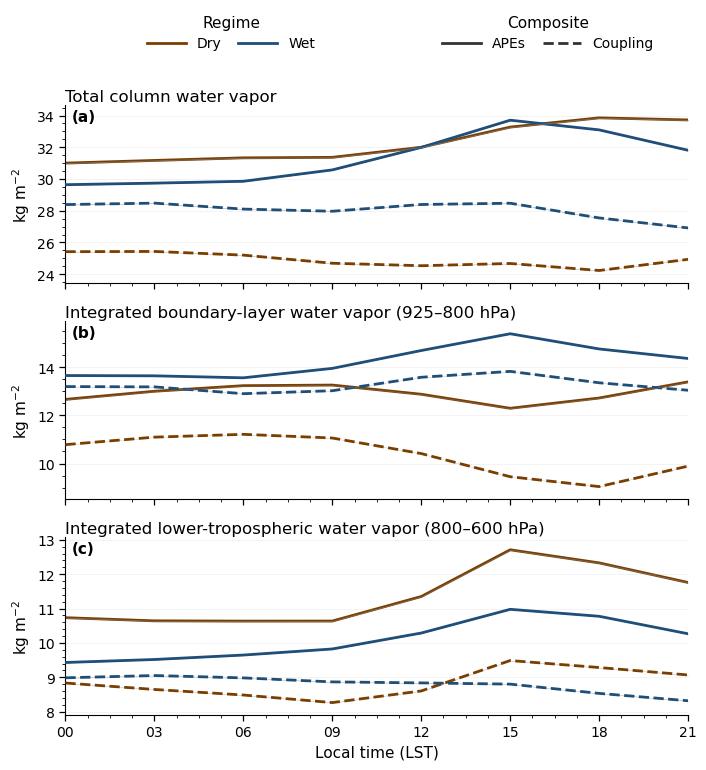

In [12]:
hours = np.arange(0, 24, 3)

plot_diurnal_cwv_3panel_journal(
    hours,
    # Total column means
    cwv_dry=diurnal_cwv_dryapes,
    cwv_wet=diurnal_cwv_wetapes,
    cwv_dryc=diurnal_cwv_drycoupling,
    cwv_wetc=diurnal_cwv_wetcoupling,
    # Total column SE (still pass these even if not used for shading)
    cwv_se_dry=se_dryapes,
    cwv_se_wet=se_wetapes,
    cwv_se_dryc=se_drycoupling,
    cwv_se_wetc=se_wetcoupling,
    # Total column STD
    cwv_std_dry=std_dryapes,
    cwv_std_wet=std_wetapes,
    cwv_std_dryc=std_drycoupling,
    cwv_std_wetc=std_wetcoupling,
    # BL means
    bl_dry=bl_diurnal_cwv_dryapes,
    bl_wet=bl_diurnal_cwv_wetapes,
    bl_dryc=bl_diurnal_cwv_drycoupling,
    bl_wetc=bl_diurnal_cwv_wetcoupling,
    # BL SE
    bl_se_dry=bl_se_dryapes,
    bl_se_wet=bl_se_wetapes,
    bl_se_dryc=bl_se_drycoupling,
    bl_se_wetc=bl_se_wetcoupling,
    # BL STD
    bl_std_dry=bl_std_dryapes,
    bl_std_wet=bl_std_wetapes,
    bl_std_dryc=bl_std_drycoupling,
    bl_std_wetc=bl_std_wetcoupling,
    # LT means
    lt_dry=lt_diurnal_cwv_dryapes,
    lt_wet=lt_diurnal_cwv_wetapes,
    lt_dryc=lt_diurnal_cwv_drycoupling,
    lt_wetc=lt_diurnal_cwv_wetcoupling,
    # LT SE
    lt_se_dry=lt_se_dryapes,
    lt_se_wet=lt_se_wetapes,
    lt_se_dryc=lt_se_drycoupling,
    lt_se_wetc=lt_se_wetcoupling,
    # LT STD
    lt_std_dry=lt_std_dryapes,
    lt_std_wet=lt_std_wetapes,
    lt_std_dryc=lt_std_drycoupling,
    lt_std_wetc=lt_std_wetcoupling,
    shading='ci',
)